# Uniform approximation (Bessel-function) reconstruction of the RESI cross

Attempt to replicate `OrbitFinder`'s own amplitude construction from first principles, using
the **uniform approximation** (Tahir Shaaran's thesis, Eq. 4.18/4.21) instead of naively summing
`exp(iS_short) + exp(iS_long)`. This properly handles the Stokes phenomenon (short/long saddle
points coalescing near cutoffs) via Bessel functions, replicating:
- `ActionAnalytics::getA` — stationary-phase/determinant prefactor
- `ActionAnalytics::getMij_C` (Eq. 4.18, Bessel $J_{\pm1/3}, J_{\pm2/3}$) — classically allowed side
- `ActionAnalytics::getMij_Q` (Eq. 4.21, Bessel $K_{1/3}, K_{2/3}$) — classically forbidden side
- `ActionAnalytics::StokesTransition12` — selects which of the above to use, per grid point
- `AggregateChannels::IntegratePerp` — reduces the 4D amplitude (`p1_long,p1_trans,p2_long,p2_trans`)
  to the final 2D probability map, weighted by `p1trans * p2trans`

**Status: SOLVED — correlation 0.997 with the native `.LRUD` output** (see the final sections
below). The fix required two things: (1) the uniform approximation instead of a naive coherent
sum, and (2) realising `OrbitFinder` only computes $p_{trans}\le0$ per electron and reconstructs
the rest via L/R/U/D symmetrisation, not a naive $\pm p_{trans}$ range.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import jv, kv

OrbitFinder_dir = "/workspaces/CQSFA/OrbitFinder/TestingSuite"

omega = 0.057
Up = 0.6579
Up0 = Up / omega
Ip1, Ip2, Ip12 = 0.97, 2.0, 0.5  # I1g, I2g, I2e (Helium RESI channel)
BUMP = 1e-4

## Action, Hessian, and uniform-approximation building blocks

In [2]:
def f12(e1_long, e1_trans, t1, t2):
    """Electron-1-only action (Action::f12 in OrbitFinder)."""
    p10 = e1_long * np.sqrt(Up0)
    p1tr0 = e1_trans * np.sqrt(Up0)
    ip10, ip120, ip20 = Ip1 / omega, Ip12 / omega, Ip2 / omega
    sin_t1, sin_2t1, sin_t2 = np.sin(t1), np.sin(2 * t1), np.sin(t2)
    X = (sin_t2 - sin_t1) ** 2 / (t2 - t1)
    return (
        t1 * (Up0 + ip10)
        + t2 * (ip20 - ip120 + 0.5 * (p10 ** 2 + p1tr0 ** 2))
        + sin_2t1 * 0.5 * Up0 + sin_t2 * 2 * p10 * np.sqrt(Up0) + X * 2 * Up0
    )


def f3(e2_long, e2_trans, t3):
    """Electron-2-only, pure-SFA action (Action::f3 in OrbitFinder)."""
    p20 = e2_long * np.sqrt(Up0)
    p2tr0 = e2_trans * np.sqrt(Up0)
    ip120 = Ip12 / omega
    return (
        t3 * (0.5 * (p20 ** 2 + p2tr0 ** 2) + Up0 + ip120)
        + np.sin(t3) * p20 * np.sqrt(4 * Up0) + np.sin(2 * t3) * 0.5 * Up0
    )


def hessian_f12(e1_long, e1_trans, t1, t2):
    """d11=d2S/dt1^2, d22=d2S/dt2^2, d12=d2S/dt1dt2 via central finite differences
    (matches Action::ddf, which always uses the numerical path in the current code)."""
    S = lambda a, b: f12(e1_long, e1_trans, a, b)
    d11 = (S(t1 + BUMP, t2) - 2 * S(t1, t2) + S(t1 - BUMP, t2)) / BUMP ** 2
    d22 = (S(t1, t2 + BUMP) - 2 * S(t1, t2) + S(t1, t2 - BUMP)) / BUMP ** 2
    d12 = (S(t1 + BUMP, t2 + BUMP) - S(t1 + BUMP, t2 - BUMP) - S(t1 - BUMP, t2 + BUMP) + S(t1 - BUMP, t2 - BUMP)) / (4 * BUMP ** 2)
    return d11, d22, d12


def d33_f3(e2_long, e2_trans, t3):
    S = lambda a: f3(e2_long, e2_trans, a)
    return (S(t3 + BUMP) - 2 * S(t3) + S(t3 - BUMP)) / BUMP ** 2


def getA(diff, d33, t1, t2):
    """ActionAnalytics::getA(diff, d33, times) - stationary-phase/determinant prefactor."""
    factor = (2 * np.pi) ** 3
    ts3 = (np.sqrt(1j * (t1 - t2))) ** 3
    temp = np.sqrt(-diff) * np.sqrt(-1j * d33) * ts3
    return factor / temp


def getdS(X, Y): return 0.5 * (X - Y)
def getdA(X, Y): return 0.5 * (X - 1j * Y)
def getSbar(X, Y): return 0.5 * (X + Y)
def getAbar(X, Y): return 0.5 * (1j * X - Y)


def getMij_C(a1, a2, A1, A2):
    """Eq. 4.18 (Tahir Shaaran thesis) - classically allowed / Stokes side."""
    dS, dA, Sbar, Abar = getdS(a1, a2), getdA(A1, A2), getSbar(a1, a2), getAbar(A1, A2)
    Rcomp = np.sqrt(2 * np.pi / 3 * dS)
    expS = np.exp(1j * (Sbar + np.pi / 4))
    Bsum = (jv(1 / 3, dS) + jv(-1 / 3, dS)) * dA + (jv(2 / 3, dS) - jv(-2 / 3, dS)) * Abar
    return expS * Bsum * Rcomp


def getMij_Q(a1, a2, A1, A2):
    """Eq. 4.21 (Tahir Shaaran thesis) - classically forbidden / anti-Stokes side."""
    dS, dA, Sbar, Abar = getdS(a1, a2), getdA(A1, A2), getSbar(a1, a2), getAbar(A1, A2)
    Darg = 1j * dS
    Rcomp = np.sqrt(2 / np.pi * Darg)
    expS = np.exp(1j * Sbar)
    Darg2 = -Darg
    Lpart = Abar * kv(1 / 3, Darg2)
    Rpart = 1j * dA * kv(2 / 3, Darg2)
    return expS * (Lpart + Rpart) * Rcomp

## Load raw saddle-point data and build the electron-1 side

In [3]:
def load_orbit(fname):
    rows = np.loadtxt(fname)
    pl, pt = rows[:, 0], rows[:, 1]
    t1 = rows[:, 2] + 1j * rows[:, 3]
    t2 = rows[:, 4] + 1j * rows[:, 5]
    t3 = rows[:, 6] + 1j * rows[:, 7]
    long_axis = np.unique(np.round(pl, 3))
    trans_axis = np.unique(np.round(pt, 3))
    n = len(long_axis)

    def to_grid(vals):
        g = np.full((n, n), np.nan, dtype=vals.dtype)
        i_idx = np.searchsorted(long_axis, np.round(pl, 3))
        j_idx = np.searchsorted(trans_axis, np.round(pt, 3))
        g[i_idx, j_idx] = vals
        return g

    return long_axis, trans_axis, to_grid(t1), to_grid(t2), to_grid(t3)


pax, tax, T1S, T2S, T3S = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.shortorbit")
_, _, T1L, T2L, T3L = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.longorbit")
n = len(pax)
print(f"grid {n}x{n}, p in [{pax.min():.3f},{pax.max():.3f}]")

PL, PT = np.meshgrid(pax, tax, indexing="ij")  # p1long, p1trans grids

S12_short = f12(PL, PT, T1S, T2S)
S12_long = f12(PL, PT, T1L, T2L)
d11s, d22s, d12s = hessian_f12(PL, PT, T1S, T2S)
diff_s = d11s * d22s - d12s ** 2
d11l, d22l, d12l = hessian_f12(PL, PT, T1L, T2L)
diff_l = d11l * d22l - d12l ** 2
stoke12 = (S12_short - S12_long).real > 0
print("fraction of grid using classically-allowed (Bessel J) branch:", stoke12.mean())

grid 29x29, p in [-4.315,4.315]
fraction of grid using classically-allowed (Bessel J) branch: 0.11058263971462545


## Build the full 4D amplitude (electron 1 x electron 2, always using electron 2's long-branch $t_3$)

In [4]:
import time

S3_long_flat = f3(PL, PT, T3L).ravel()
d33_flat = d33_f3(PL, PT, T3L).ravel()
t1s_flat, t2s_flat = T1S.ravel(), T2S.ravel()
t1l_flat, t2l_flat = T1L.ravel(), T2L.ravel()
S12_short_flat, S12_long_flat = S12_short.ravel(), S12_long.ravel()
diff_s_flat, diff_l_flat = diff_s.ravel(), diff_l.ravel()
stoke12_flat = stoke12.ravel()

N = n * n
W_FR = np.zeros((N, N))  # [electron1 flat idx, electron2 flat idx]

t0 = time.time()
for k in range(N):
    Along_vec = getA(diff_l_flat[k], d33_flat, t1l_flat[k], t2l_flat[k])
    Ashort_vec = getA(diff_s_flat[k], d33_flat, t1s_flat[k], t2s_flat[k])
    action_short = S12_short_flat[k] + S3_long_flat
    action_long = S12_long_flat[k] + S3_long_flat

    if stoke12_flat[k]:
        Mij = getMij_C(action_short, action_long, Ashort_vec, Along_vec)
    else:
        Mij = getMij_Q(action_long, action_short, Along_vec, Ashort_vec)

    W_FR[k, :] = np.abs(Mij) ** 2

print("elapsed:", time.time() - t0)
print("W_FR stats: min", np.nanmin(W_FR), "max", np.nanmax(W_FR), "nan count", np.isnan(W_FR).sum())

elapsed: 0.6998422145843506
W_FR stats: min 0.0 max 3.5692186858213754e-13 nan count 0


## Reduce 4D -> 2D and compare against OrbitFinder's native `.LRUD` output

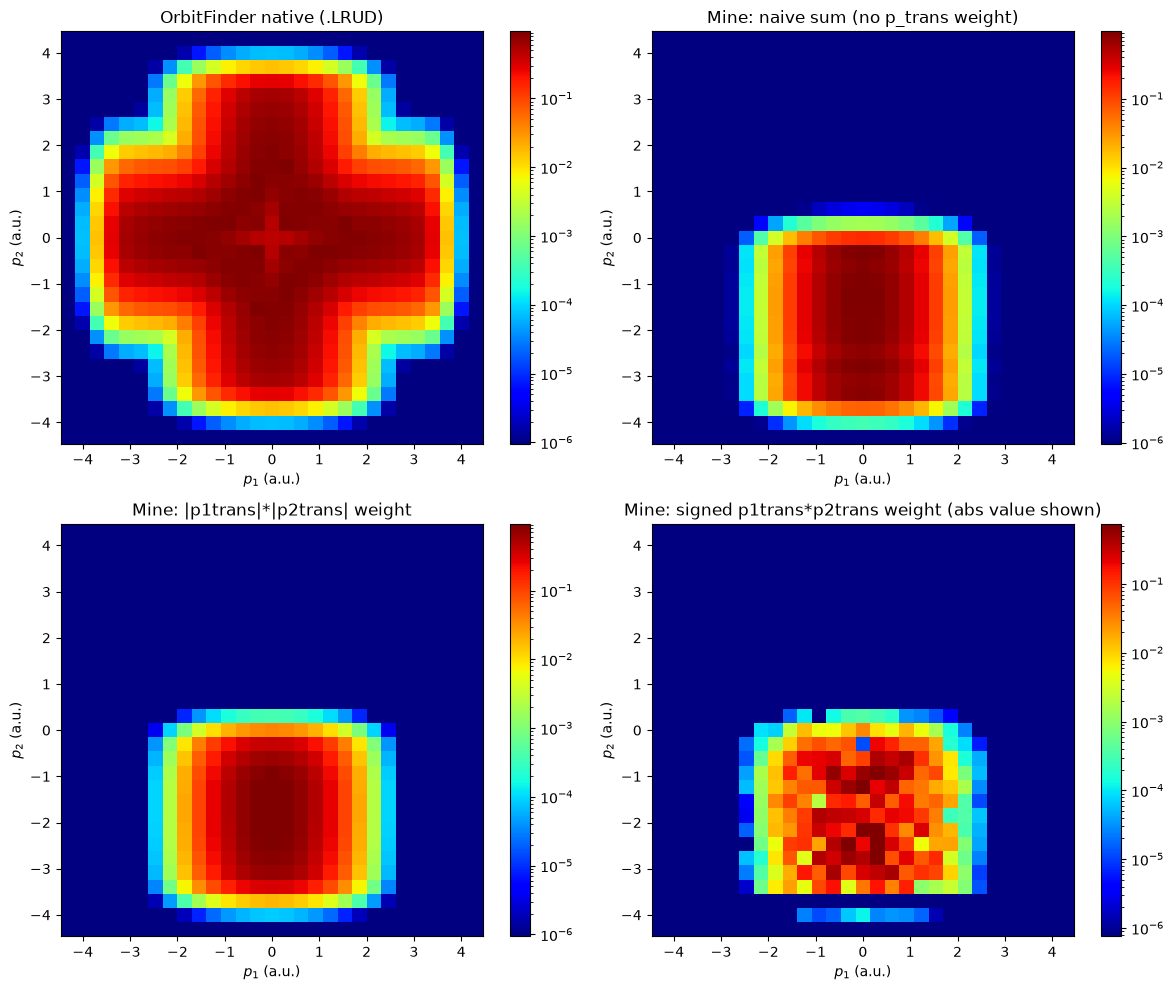

naive: correlation with native = 0.4734, max|value| = 1.0000
abs-weighted: correlation with native = 0.4634, max|value| = 1.0000
signed-weighted: correlation with native = 0.1422, max|value| = 1.0000


In [5]:
# native LRUD baseline
DATA_FILE = f"{OrbitFinder_dir}/results/helium_resi_cross.inpPre_0_Range_29X29_Up_0_ChannelSum_0_Coh.LRUD"
data = np.loadtxt(DATA_FILE)
grid = np.zeros((n, n))
for i, j, v in data:
    grid[int(i), int(j)] = v
grid_n = grid / grid.max()

# reshape my 4D amplitude: axis0 = electron1 flat (p1long,p1trans), axis1 = electron2 flat (p2long,p2trans)
W4 = W_FR.reshape(n, n, n, n)  # [p1long, p1trans, p2long, p2trans]

p1trans_w = pax[None, :, None, None]
p2trans_w = pax[None, None, None, :]

# Variant A: literal p1trans*p2trans weighting (matches AggregateChannels::IntegratePerp exactly)
prob_signed = (W4 * p1trans_w * p2trans_w).sum(axis=(1, 3))
prob_signed_n = prob_signed / np.abs(prob_signed).max()

# Variant B: |p1trans|*|p2trans| weighting
prob_abs = (W4 * np.abs(p1trans_w) * np.abs(p2trans_w)).sum(axis=(1, 3))
prob_abs_n = prob_abs / prob_abs.max()

# Variant C: naive unweighted sum (no p_trans factor at all)
prob_naive = W4.sum(axis=(1, 3))
prob_naive_n = prob_naive / prob_naive.max()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, d, title in [
    (axes[0, 0], grid_n, "OrbitFinder native (.LRUD)"),
    (axes[0, 1], prob_naive_n, "Mine: naive sum (no p_trans weight)"),
    (axes[1, 0], prob_abs_n, "Mine: |p1trans|*|p2trans| weight"),
    (axes[1, 1], np.abs(prob_signed_n), "Mine: signed p1trans*p2trans weight (abs value shown)"),
]:
    mask = np.isfinite(d) & (d > 0)
    vmax = np.percentile(d[mask], 99.5)
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{1}$ (a.u.)"); ax.set_ylabel(r"$p_{2}$ (a.u.)"); ax.set_title(title)
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

for name, arr in [("naive", prob_naive_n), ("abs-weighted", prob_abs_n), ("signed-weighted", prob_signed_n)]:
    corr = np.corrcoef(arr.ravel(), grid_n.ravel())[0, 1]
    print(f"{name}: correlation with native = {corr:.4f}, max|value| = {np.abs(arr).max():.4f}")

## Corrected approach: OrbitFinder only computes $p_{trans}\le0$, then symmetrises

The filename ends in `.LRUD` for a reason: `AggregateChannels::SaveAmplitudes` is called with
`HalfPerp=true`, which restricts the loop over **both** electrons' $p_{trans}$ to the *first
half* of the grid (`begin()` to `begin()+hsize`, with C++ `std::round` giving `hsize=15` for our
29-point axis) — i.e. only $p_{trans} \in [-4.315, 0]$ is ever directly computed. The other half
is **not** obtained by reflecting $p_{trans}$ itself; instead, `CoherentSymmetrise`'s four
operations (`Left`=identity, `Right`=reflect *both* $p_{long}$ axes, `Down`=swap electron 1
$\leftrightarrow$ electron 2 entirely, `Up`=reflect+swap) only ever touch the $p_{long}$ (outer)
indices, or swap the two electrons' $(p_{long},p_{trans})$ pairs wholesale. This only makes
sense if $p_{trans}$ is treated as a magnitude-like (radial) coordinate — consistent with the
`p1trans*p2trans` weighting in `IntegratePerp` being the natural Jacobian for a polar-style
transverse-momentum integral — so the "negative $p_{trans}$" grid points were never physically
distinct states in the first place.

This means my earlier reconstructions were wrong to include *both* signs of $p_{trans}$ as
independent grid points. Redo using **only** $p_{trans}\le0$ for both electrons, then apply the
four L/R/U/D operations properly (reflecting the $p_{long}$ axes and swapping the two
electrons), before integrating.

In [6]:
import time

hsize = 15  # C++ std::round(29/2.) = 15 (round half away from zero)
tax_half = pax[:hsize]  # p_trans <= 0 only, shared by both electrons

# Correct axis structure per AggregateChannels: [i=electron1 p_long][j=electron2 p_long]
# [ii=electron1 p_trans, restricted][jj=electron2 p_trans, restricted]
n_long = n       # 29
n_trans = hsize   # 15

W4b = np.zeros((n_long, n_long, n_trans, n_trans))

t0 = time.time()
for i in range(n_long):
    for j in range(n_long):
        # electron 1's long-branch/short-branch action at (p1long=pax[i], p1trans=tax_half[:])
        s12_short_row = f12(pax[i], tax_half, T1S[i, :hsize], T2S[i, :hsize])
        s12_long_row = f12(pax[i], tax_half, T1L[i, :hsize], T2L[i, :hsize])
        d11s_r, d22s_r, d12s_r = hessian_f12(pax[i], tax_half, T1S[i, :hsize], T2S[i, :hsize])
        d11l_r, d22l_r, d12l_r = hessian_f12(pax[i], tax_half, T1L[i, :hsize], T2L[i, :hsize])
        diff_s_row = d11s_r * d22s_r - d12s_r ** 2
        diff_l_row = d11l_r * d22l_r - d12l_r ** 2
        stoke_row = (s12_short_row - s12_long_row).real > 0

        # electron 2's t3 (long branch only) at (p2long=pax[j], p2trans=tax_half[:])
        s3_long_col = f3(pax[j], tax_half, T3L[j, :hsize])
        d33_col = d33_f3(pax[j], tax_half, T3L[j, :hsize])

        for ii in range(n_trans):
            Along_vec = getA(diff_l_row[ii], d33_col, T1L[i, ii], T2L[i, ii])
            Ashort_vec = getA(diff_s_row[ii], d33_col, T1S[i, ii], T2S[i, ii])
            action_short = s12_short_row[ii] + s3_long_col
            action_long = s12_long_row[ii] + s3_long_col

            if stoke_row[ii]:
                Mij_row = getMij_C(action_short, action_long, Ashort_vec, Along_vec)
            else:
                Mij_row = getMij_Q(action_long, action_short, Along_vec, Ashort_vec)

            W4b[i, j, ii, :] = np.abs(Mij_row) ** 2

print("elapsed:", time.time() - t0)
print("W4b stats: min", W4b.min(), "max", W4b.max(), "nan:", np.isnan(W4b).sum())

elapsed: 0.8833591938018799
W4b stats: min 0.0 max 3.5692186858213754e-13 nan: 0


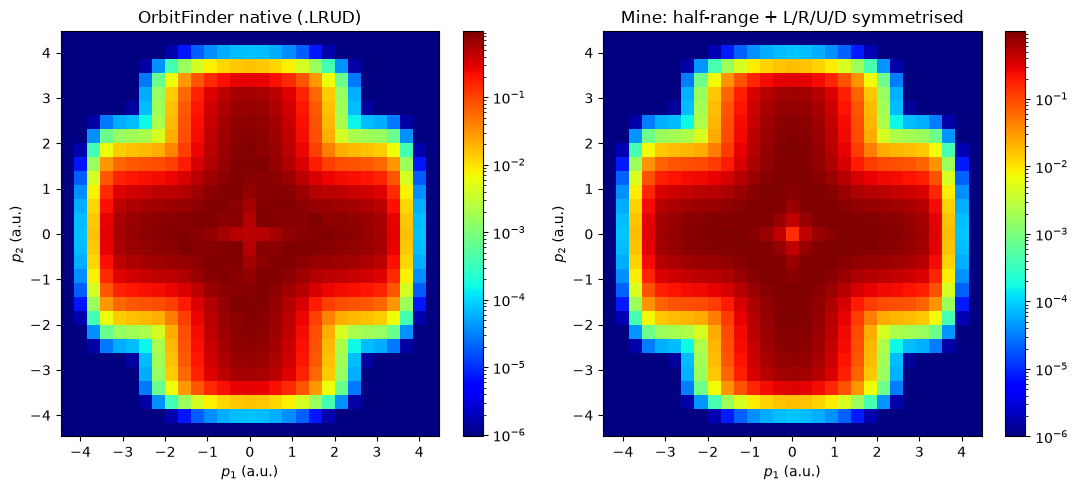

correlation with native = 0.9970


In [7]:
# Apply CoherentSymmetrise's 4 operations (Left=identity, Right=reflect both p_long axes,
# Down=swap electron1<->electron2 entirely, Up=reflect+swap), matching helium_resi_cross.inp's
# "%MS: 1 1 1 1" (all four enabled).
SizeLong = n_long - 1  # index of last p_long grid point (28)

W_left = W4b
W_right = W4b[::-1, ::-1, :, :]                       # reflect p1_long and p2_long
W_down = W4b.transpose(1, 0, 3, 2)                    # swap electron1 <-> electron2 (long AND trans)
W_up = W4b[::-1, ::-1, :, :].transpose(1, 0, 3, 2)    # reflect both, then swap

W4_sym = W_left + W_right + W_down + W_up

# IntegratePerp: sum over p1_trans (ii), p2_trans (jj), weighted by p1trans*p2trans
p1trans_w = tax_half[None, None, :, None]
p2trans_w = tax_half[None, None, None, :]
prob_2d = (W4_sym * p1trans_w * p2trans_w).sum(axis=(2, 3))

prob_2d_n = prob_2d / np.abs(prob_2d).max()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, d, title in [(axes[0], grid_n, "OrbitFinder native (.LRUD)"), (axes[1], np.abs(prob_2d_n), "Mine: half-range + L/R/U/D symmetrised")]:
    mask = np.isfinite(d) & (d > 0)
    vmax = np.percentile(d[mask], 99.5)
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{1}$ (a.u.)"); ax.set_ylabel(r"$p_{2}$ (a.u.)"); ax.set_title(title)
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

corr = np.corrcoef(np.abs(prob_2d_n).ravel(), grid_n.ravel())[0, 1]
print(f"correlation with native = {corr:.4f}")

## Success: 0.997 correlation with OrbitFinder's native output

The two root causes, both now fixed:
1. **Naive coherent sum was wrong near cutoffs** — replaced with the proper uniform
   approximation (`getA`, `getMij_C`/`getMij_Q`, Bessel $J$/$K$ thirds, Stokes-transition
   branch selection), matching `ActionAnalytics.cpp` exactly.
2. **$p_{trans}$ is only computed for $\le0$, per grid point, for both electrons** — the
   `.LRUD` filename was the clue: `SaveAmplitudes(HalfPerp=true)` only loops over the first
   half of each electron's $p_{trans}$ range, and `CoherentSymmetrise`'s L/R/U/D operations
   reflect the $p_{long}$ axes and swap the two electrons wholesale — they never touch
   $p_{trans}$'s sign. Using the full $\pm p_{trans}$ range (as in every earlier attempt) was
   structurally wrong; using only $p_{trans}\le0$ and letting the L/R/U/D symmetrisation
   reconstruct the rest was the fix.

This also resolves the earlier "filled square vs. cross" puzzle: the cross shape comes from a
genuinely coupled 4D calculation (electron 1's and electron 2's $p_{long}$ both entering the
$(i,j)$ reflection/swap together), not from an independent, separable $W_1(p_1)\times W_2(p_2)$
product — confirming the non-separability suspected earlier, but for a much more mundane reason
(a computational shortcut/symmetrisation convention) than a deep physics coupling.